# **AI Waste Sorting System**

A computer vision system that classifies waste into categories.

**Classes**:
- Plastic
- Metal
- Paper
- Glass
- Organic waste
<br/>

**Objective**:
Built an AI system to assist automated recycling by classifying waste images using CNN models.
<br/>

**What makes it impressive**

Instead of basic classification, I will include:
- **Real-time classification with webcam**
- **3D simulation integration**
<br/>

**Dataset**
- [TrashNet dataset](https://github.com/garythung/trashnet/blob/master/data/dataset-resized.zip)
- TACO dataset

In [1]:
!pip install split-folders

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

import requests
import zipfile
import shutil
from pathlib import Path
import splitfolders

from timeit import default_timer as timer
from tqdm.auto import tqdm


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
## getting the dataset

data_path = Path("data/")
image_path = data_path / "images"

zip_file = data_path / "dataset-resized.zip"
if not zip_file.is_file():
    data_path.mkdir(parents = True, exist_ok = True)
    print("Downloading trash net dataset...")
    with open(zip_file, "wb") as f:
        request = requests.get("https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip")
        f.write(request.content)
else:
    print(f"{zip_file} already exists, skipping download.")

if not image_path.is_dir():
    print("Unzipping and organizing...")
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(data_path)

    temp_folder = data_path / "dataset-resized"
    if temp_folder.exists():
        temp_folder.rename(image_path)

    zip_file.unlink()
    macosx_folder = data_path / "__MACOSX"
    if macosx_folder.exists():
        shutil.rmtree(macosx_folder)

    print(f"Done! Your data is in {image_path}")
else:
    print(f"{image_path} already exists.")

Unzipping and organizing...
Done! Your data is in data/images


In [5]:
## splitting dataset dir into train/ and test/

input_folder = "data/images"
output_folder = "data/split_data"

splitfolders.ratio(input_folder, output = output_folder, seed = 42, ratio = (.8,.2))

print("Successfully split data into train and test folders!")

Copying files: 2527 files [00:01, 1864.25 files/s]

Successfully split data into train and test folders!


In [8]:
## transform
# using transform.Normalize

data_transform = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # adding ImageNet stats
])

In [9]:
## Loading custom dataset image

train_data = datasets.ImageFolder(
    root = "data/split_data/train",
    transform = data_transform,
    target_transform = None
)

test_data = datasets.ImageFolder(
    root = "data/split_data/test",
    transform = data_transform,
)

In [10]:
train_dataloader = DataLoader(
    train_data,
    batch_size = 32,
    shuffle = True,
    num_workers = 1
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size = 32,
    shuffle = False,
    num_workers = 1
)

In [12]:
len(train_dataloader), len(test_dataloader)

(64, 16)

In [13]:
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 2019
     Root location: data/split_data/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset ImageFolder
     Number of datapoints: 508
     Root location: data/split_data/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ))

In [15]:
class_names = train_data.classes
class_names

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [16]:
class_dict = train_data.class_to_idx
class_dict

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

In [17]:
train_data[0]

(tensor([[[ 2.0605,  2.0434,  2.0434,  ...,  1.4954,  1.5810,  1.5982],
          [ 2.0434,  2.0434,  2.0263,  ...,  1.4783,  1.5468,  1.5982],
          [ 2.0092,  1.9920,  2.0434,  ...,  1.4612,  1.5125,  1.5468],
          ...,
          [ 0.9132,  0.8618,  0.7419,  ..., -0.1828, -0.1828, -0.2342],
          [ 0.9474,  0.8961,  0.7762,  ..., -0.1657, -0.1657, -0.1828],
          [ 1.0331,  0.8961,  0.6906,  ..., -0.1657, -0.1828, -0.1657]],
 
         [[ 1.5357,  1.5182,  1.5007,  ...,  0.8880,  0.9755,  0.9930],
          [ 1.5182,  1.5182,  1.4832,  ...,  0.8704,  0.9405,  0.9930],
          [ 1.5007,  1.5007,  1.5182,  ...,  0.8704,  0.9230,  0.9580],
          ...,
          [ 0.4328,  0.4153,  0.3978,  ..., -0.4776, -0.4951, -0.5476],
          [ 0.4328,  0.4503,  0.4153,  ..., -0.4601, -0.4776, -0.4951],
          [ 0.5203,  0.4503,  0.3277,  ..., -0.4601, -0.4951, -0.4776]],
 
         [[ 1.1411,  1.1411,  1.1934,  ...,  0.6008,  0.6879,  0.7054],
          [ 1.1237,  1.1237,

In [18]:
img, label = train_data[0][0], train_data[0][1]

In [19]:
img.shape

torch.Size([3, 64, 64])

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

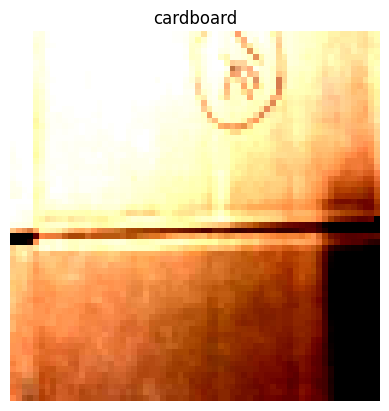

In [20]:
plt.imshow(img.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)

In [21]:
img, label = next(iter(train_dataloader))
print(f"Image shape: {img.shape}")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])


In [22]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc

In [23]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device = device):
  model.eval()

  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim = 1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)

  return test_loss, test_acc


In [24]:
def train(epochs: int,
          model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          scheduler: None):

  results = {
      "train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(
                                model = model,
                                dataloader = train_dataloader,
                                loss_fn = loss_fn,
                                optimizer = optimizer,
                            )
    test_loss, test_acc = test_step(
                              model = model,
                              dataloader = test_dataloader,
                              loss_fn = loss_fn,
                              device = device
                          )

    # Updating the scheduler here
    if scheduler is not None:
        # For ReduceLROnPlateau, we pass the metric we want to monitor
        scheduler.step(test_loss)

        # Optional: Print the current LR to see it change in your logs
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current Learning Rate: {current_lr:.6f}")

    print(f"Epoch: {epoch} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f}% | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}%")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

In [25]:
from typing import Dict, List

def plot_loss_curves(results: Dict[str, List[float]]):
  ''' Plot training curves of a result dictionary '''
  # Get the loss values of the results dictionary(training and tes)
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  # Get the accuracy values of the results dictionary  (training and test)
  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  # Figure out how many epochs there were
  epochs = range(len(results["train_loss"]))

  # Setup a plot
  plt.figure(figsize = (15, 7))

  # Plot the loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label = "train_loss")
  plt.plot(epochs, test_loss, label = "test_loss")
  plt.title("loss")
  plt.xlabel("epochs")
  plt.legend()

  # Plot the accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label = "train_accuracy")
  plt.plot(epochs, test_accuracy, label = "test_accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend()

In [38]:
class WasteCNN_1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units*2, 3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block_3 = nn.Sequential(
            nn.Conv2d(hidden_units*2, hidden_units*4, 3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=1), # adding GlobalAvgPool to my MaxPool only at the end
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=hidden_units*4, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.classifier(x)

        return x

In [39]:
model_1 = WasteCNN_1(
    input_shape = 3,
    hidden_units = 32,
    output_shape = len(class_names)
).to(device)

In [57]:
# Trying to higher accuracy

class WasteCNN_2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*2, out_channels=hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units*2, out_channels=hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*4, out_channels=hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block_4 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units*4, out_channels=hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*8, out_channels=hidden_units*8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=1),
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=hidden_units*8, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.conv_block_4(x)
        x = self.classifier(x)

        return x

In [58]:
model_2 = WasteCNN_2(
    input_shape = 3,
    hidden_units = 32,
    output_shape = len(class_names)
).to(device)

In [43]:
# training and testing
# lr = 0.001, epoch = 30

optimizer = torch.optim.Adam(params = model_1.parameters(), lr = 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)
loss_fn = nn.CrossEntropyLoss()

In [44]:
results = train(
    epochs = 30,
    model = model_1,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/30 [00:00<?, ?it/s]

Current Learning Rate: 0.001000
Epoch: 0 | train_loss: 1.3768 | train_acc: 0.4714% | test_loss: 1.3819 | test_acc: 0.4420%
Current Learning Rate: 0.001000
Epoch: 1 | train_loss: 1.2490 | train_acc: 0.5213% | test_loss: 1.2172 | test_acc: 0.5312%
Current Learning Rate: 0.001000
Epoch: 2 | train_loss: 1.1809 | train_acc: 0.5410% | test_loss: 1.1515 | test_acc: 0.5508%
Current Learning Rate: 0.001000
Epoch: 3 | train_loss: 1.0980 | train_acc: 0.5934% | test_loss: 1.1149 | test_acc: 0.5608%
Current Learning Rate: 0.001000
Epoch: 4 | train_loss: 1.0693 | train_acc: 0.5955% | test_loss: 1.0671 | test_acc: 0.5698%
Current Learning Rate: 0.001000
Epoch: 5 | train_loss: 1.0355 | train_acc: 0.6157% | test_loss: 1.0653 | test_acc: 0.5879%
Current Learning Rate: 0.001000
Epoch: 6 | train_loss: 0.9641 | train_acc: 0.6457% | test_loss: 1.3423 | test_acc: 0.5184%
Current Learning Rate: 0.001000
Epoch: 7 | train_loss: 0.9783 | train_acc: 0.6302% | test_loss: 1.1226 | test_acc: 0.5541%
Current Learning

In [45]:
results

{'train_loss': [1.3767701908946037,
  1.2489553950726986,
  1.1809359574690461,
  1.097986371256411,
  1.0693463636562228,
  1.035496429540217,
  0.9640984013676643,
  0.9782879995182157,
  0.961853476241231,
  0.9429215672425926,
  0.9074431136250496,
  0.9050278514623642,
  0.9118637875653803,
  0.885997561737895,
  0.8458797419443727,
  0.8069469919428229,
  0.7724705208092928,
  0.778265930712223,
  0.7629061071202159,
  0.7547906548716128,
  0.740146063733846,
  0.7319100652821362,
  0.731394873932004,
  0.6971439230255783,
  0.692918804474175,
  0.6916904901154339,
  0.7344582239165902,
  0.6843824428506196,
  0.6837386335246265,
  0.6612623240798712],
 'train_acc': [0.4713541666666667,
  0.5213216145833334,
  0.541015625,
  0.5934244791666666,
  0.5955403645833334,
  0.61572265625,
  0.6456705729166666,
  0.6302083333333334,
  0.64306640625,
  0.642578125,
  0.6573893229166666,
  0.6728515625,
  0.6774088541666666,
  0.6793619791666666,
  0.6842447916666666,
  0.7086588541666666

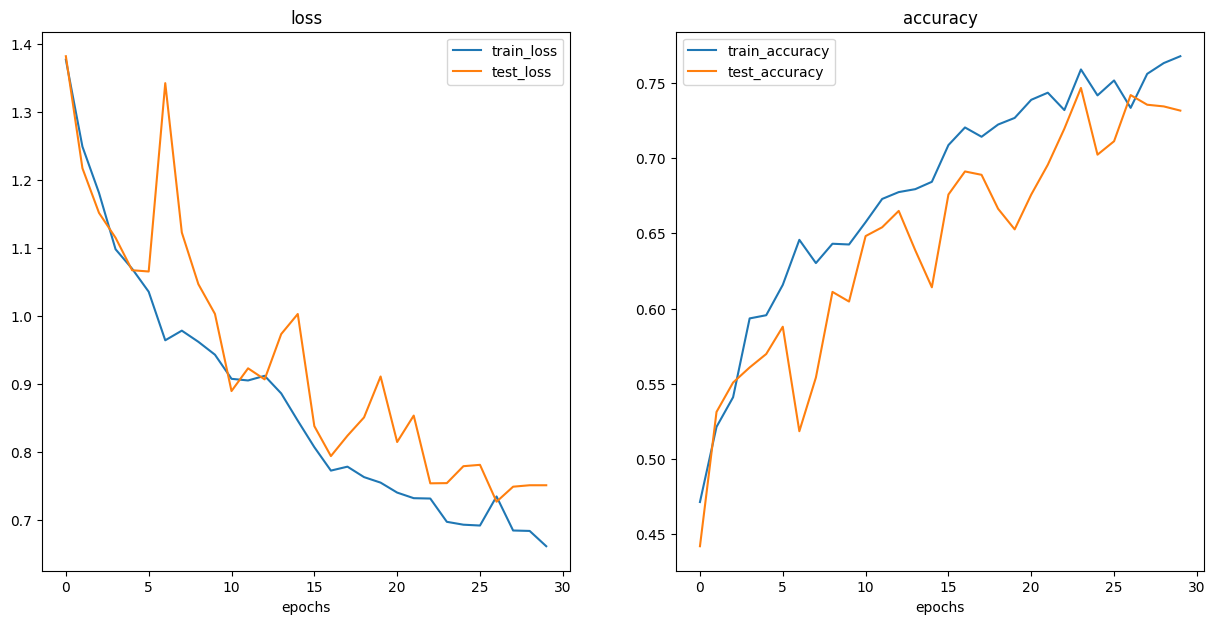

In [46]:
plot_loss_curves(results)

In [59]:
optimizer = torch.optim.Adam(params = model_2.parameters(), lr = 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)
loss_fn = nn.CrossEntropyLoss()

In [60]:
results = train(
    epochs = 30,
    model = model_2,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/30 [00:00<?, ?it/s]

Current Learning Rate: 0.001000
Epoch: 0 | train_loss: 1.3155 | train_acc: 0.5055% | test_loss: 1.1964 | test_acc: 0.5547%
Current Learning Rate: 0.001000
Epoch: 1 | train_loss: 1.1622 | train_acc: 0.5809% | test_loss: 1.5409 | test_acc: 0.4824%
Current Learning Rate: 0.001000
Epoch: 2 | train_loss: 1.1014 | train_acc: 0.5910% | test_loss: 1.0345 | test_acc: 0.5979%
Current Learning Rate: 0.001000
Epoch: 3 | train_loss: 1.0597 | train_acc: 0.6090% | test_loss: 1.1438 | test_acc: 0.5868%
Current Learning Rate: 0.001000
Epoch: 4 | train_loss: 0.9902 | train_acc: 0.6359% | test_loss: 1.1551 | test_acc: 0.5798%
Current Learning Rate: 0.001000
Epoch: 5 | train_loss: 1.0056 | train_acc: 0.6250% | test_loss: 1.1457 | test_acc: 0.6169%
Current Learning Rate: 0.000500
Epoch: 6 | train_loss: 0.9635 | train_acc: 0.6512% | test_loss: 1.5429 | test_acc: 0.5098%
Current Learning Rate: 0.000500
Epoch: 7 | train_loss: 0.8018 | train_acc: 0.6994% | test_loss: 0.8932 | test_acc: 0.6744%
Current Learning

In [61]:
results

{'train_loss': [1.3154539801180363,
  1.1622341638430953,
  1.1014190083369613,
  1.0596532225608826,
  0.990160115994513,
  1.0055562602356076,
  0.9635276198387146,
  0.8017662884667516,
  0.7911490676924586,
  0.740135776810348,
  0.7140085832215846,
  0.6970694749616086,
  0.6495318179950118,
  0.6415569013915956,
  0.6846453305333853,
  0.6072496525011957,
  0.6132391416467726,
  0.6515182950533926,
  0.5368327801115811,
  0.5639132363721728,
  0.5589765487238765,
  0.4766375217586756,
  0.4887888936791569,
  0.4757230933755636,
  0.49783640704117715,
  0.4525103138294071,
  0.39311763003934175,
  0.35492668650113046,
  0.33119666879065335,
  0.3214046647772193],
 'train_acc': [0.5055338541666666,
  0.5808919270833334,
  0.5909830729166666,
  0.6090494791666666,
  0.6359049479166666,
  0.625,
  0.6512044270833334,
  0.6993815104166666,
  0.7223307291666666,
  0.740234375,
  0.7449544270833334,
  0.7443033854166666,
  0.771484375,
  0.7706705729166666,
  0.7571614583333334,
  0.779

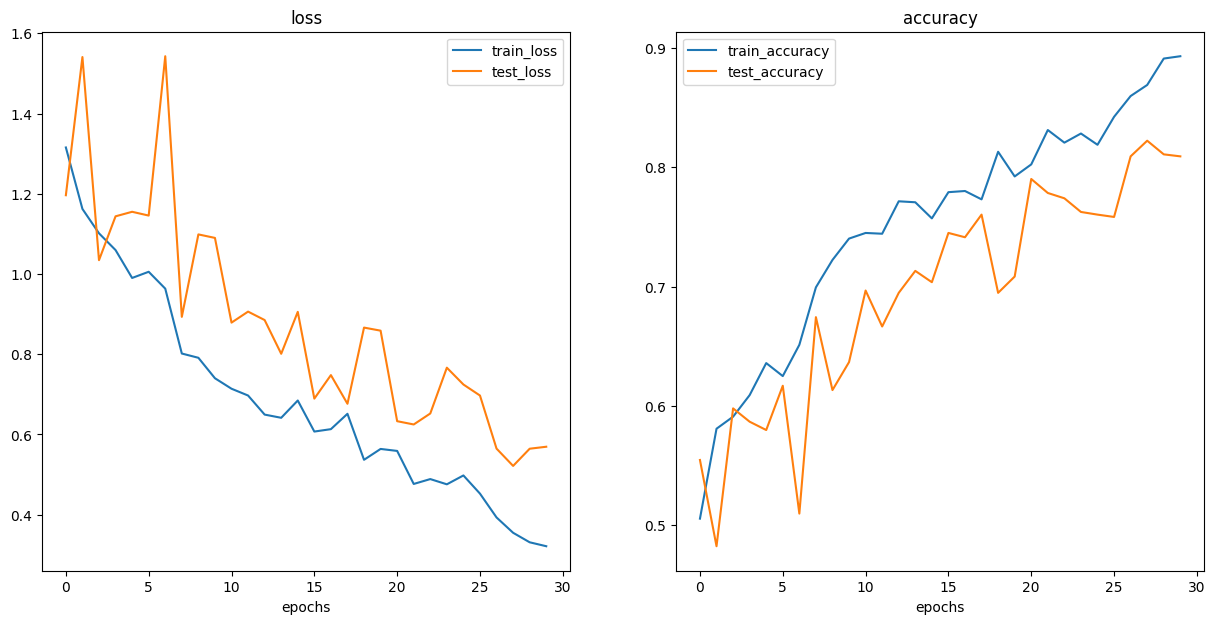

In [62]:
plot_loss_curves(results)

In [66]:
optimizer = torch.optim.Adam(params = model_1.parameters(), lr = 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)
loss_fn = nn.CrossEntropyLoss()

In [67]:
results = train(
    epochs = 50,
    model = model_1,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/50 [00:00<?, ?it/s]

Current Learning Rate: 0.001000
Epoch: 0 | train_loss: 0.7980 | train_acc: 0.7088% | test_loss: 0.9039 | test_acc: 0.6532%
Current Learning Rate: 0.001000
Epoch: 1 | train_loss: 0.7753 | train_acc: 0.7236% | test_loss: 1.3350 | test_acc: 0.5650%
Current Learning Rate: 0.001000
Epoch: 2 | train_loss: 0.7747 | train_acc: 0.7152% | test_loss: 1.0339 | test_acc: 0.6295%
Current Learning Rate: 0.001000
Epoch: 3 | train_loss: 0.7840 | train_acc: 0.7204% | test_loss: 0.8151 | test_acc: 0.7107%
Current Learning Rate: 0.001000
Epoch: 4 | train_loss: 0.7364 | train_acc: 0.7394% | test_loss: 0.7876 | test_acc: 0.7001%
Current Learning Rate: 0.001000
Epoch: 5 | train_loss: 0.7201 | train_acc: 0.7487% | test_loss: 0.8332 | test_acc: 0.6939%
Current Learning Rate: 0.001000
Epoch: 6 | train_loss: 0.7066 | train_acc: 0.7414% | test_loss: 0.7770 | test_acc: 0.7204%
Current Learning Rate: 0.001000
Epoch: 7 | train_loss: 0.7309 | train_acc: 0.7422% | test_loss: 0.9900 | test_acc: 0.6476%
Current Learning

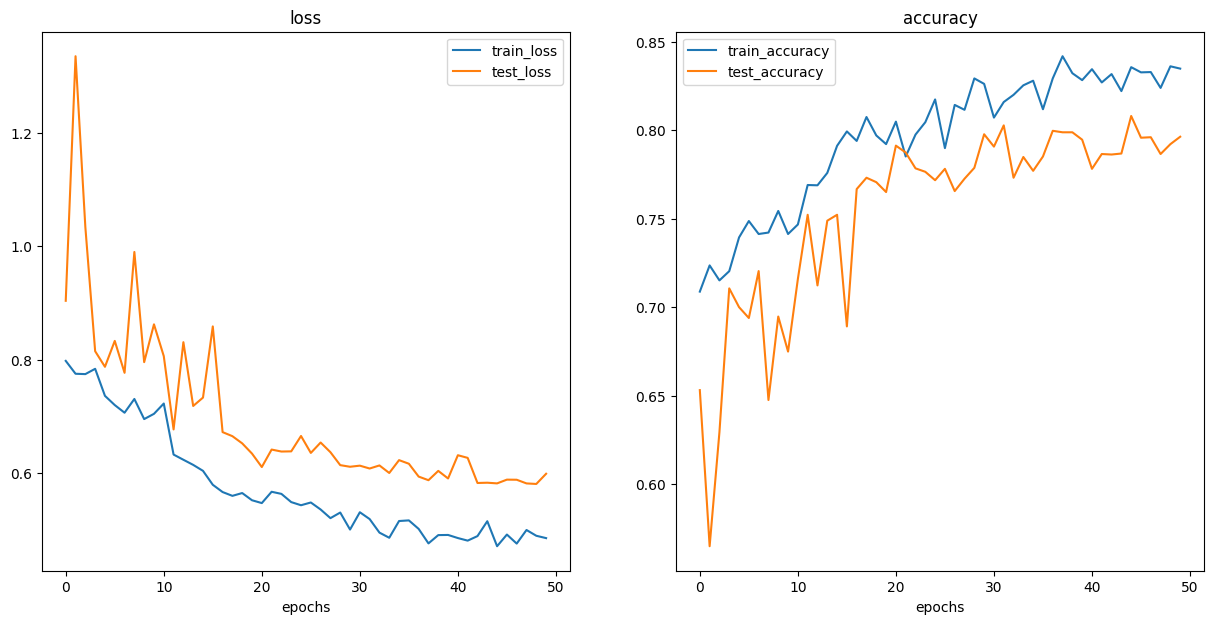

In [68]:
 plot_loss_curves(results)

In [69]:
optimizer = torch.optim.Adam(params = model_2.parameters(), lr = 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)
loss_fn = nn.CrossEntropyLoss()

In [70]:
results = train(
    epochs = 50,
    model = model_2,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    scheduler = scheduler
)

  0%|          | 0/50 [00:00<?, ?it/s]

Current Learning Rate: 0.001000
Epoch: 0 | train_loss: 0.6734 | train_acc: 0.7578% | test_loss: 0.9352 | test_acc: 0.6936%
Current Learning Rate: 0.001000
Epoch: 1 | train_loss: 0.5407 | train_acc: 0.8049% | test_loss: 0.7345 | test_acc: 0.7631%
Current Learning Rate: 0.001000
Epoch: 2 | train_loss: 0.5027 | train_acc: 0.8161% | test_loss: 0.7106 | test_acc: 0.7567%
Current Learning Rate: 0.001000
Epoch: 3 | train_loss: 0.4778 | train_acc: 0.8242% | test_loss: 0.7287 | test_acc: 0.7924%
Current Learning Rate: 0.001000
Epoch: 4 | train_loss: 0.4729 | train_acc: 0.8236% | test_loss: 0.7730 | test_acc: 0.7642%
Current Learning Rate: 0.001000
Epoch: 5 | train_loss: 0.4901 | train_acc: 0.8182% | test_loss: 0.7085 | test_acc: 0.7584%
Current Learning Rate: 0.001000
Epoch: 6 | train_loss: 0.5156 | train_acc: 0.8267% | test_loss: 0.8376 | test_acc: 0.7174%
Current Learning Rate: 0.001000
Epoch: 7 | train_loss: 0.4961 | train_acc: 0.8164% | test_loss: 0.8357 | test_acc: 0.7176%
Current Learning

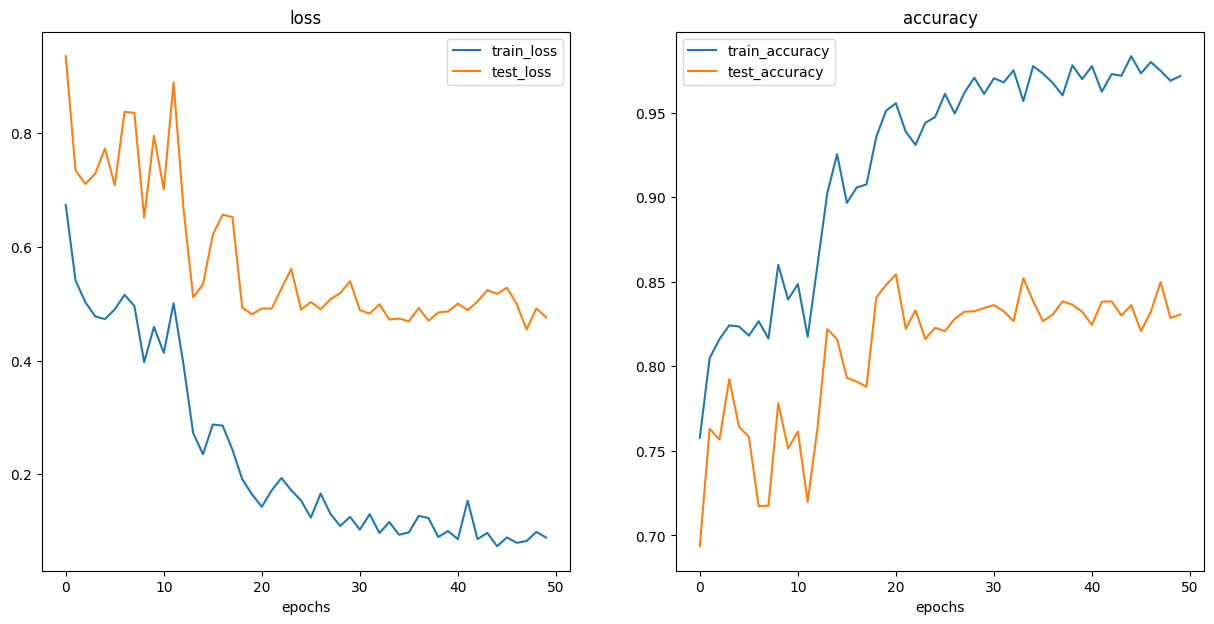

In [75]:
plot_loss_curves(results)

In [92]:
# model_2 suffer a bit from overfitting